### Import Required Libraries

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Reading and Understanding Data

In [98]:
df = pd.read_csv('bank.csv')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


<Axes: xlabel='deposit'>

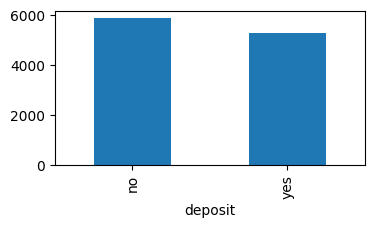

In [99]:
# distribution of deposit
plt.figure(figsize=[4,2])
df['deposit'].value_counts().plot(kind = 'bar')

In [100]:
# info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [101]:
# missing values
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

### Dropping column

In [102]:
df.drop(columns = ['contact'],inplace=True)

### Label Encoding

In [103]:
'''
1. divide data into 2 dataframe object and numeric
2. perform label encoding on object
3. concat updated object dataframe with numric
'''
df_obj = df.select_dtypes(include='object')
df_num = df.select_dtypes(include=['int','float'])

In [104]:
# importing label encoding class
from sklearn.preprocessing import LabelEncoder

#instance of a class
l = LabelEncoder()

# Label Encoding
'''
df_obj['obj'] = l.fit_transform(df_obj[job]) # methodologiy

1. make a list of columns name
2. apply for loop to iterate over a fit_transform function and store it in a same col.
'''

def label_encoding(columns):
    for col in columns:
        df_obj[col] = l.fit_transform(df_obj[col])

columns = list(df_obj.columns)

label_encoding(columns)

In [105]:
df_obj.head()

,job,marital,education,default,housing,loan,month,poutcome,deposit
0,0,1,1,0,1,0,8,3,1
1,0,1,1,0,0,0,8,3,1
2,9,1,1,0,1,0,8,3,1
3,7,1,1,0,1,0,8,3,1
4,0,1,2,0,0,0,8,3,1


In [106]:
'''
Concat both df_obj and df_num and make it df again
'''

df = pd.concat([df_num,df_obj],axis=1)

In [107]:
df.head()

,age,balance,day,duration,campaign,pdays,previous,job,marital,education,default,housing,loan,month,poutcome,deposit
0,59,2343,5,1042,1,-1,0,0,1,1,0,1,0,8,3,1
1,56,45,5,1467,1,-1,0,0,1,1,0,0,0,8,3,1
2,41,1270,5,1389,1,-1,0,9,1,1,0,1,0,8,3,1
3,55,2476,5,579,1,-1,0,7,1,1,0,1,0,8,3,1
4,54,184,5,673,2,-1,0,0,1,2,0,0,0,8,3,1


### Splitting Data into x and y


In [108]:
x = df.drop(columns = 'deposit')
y = df['deposit']

### Splitting data into train and test

In [109]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.20,random_state=1)

### Importing Model Libraries

In [110]:
# importing Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# evaluation matrix
from sklearn.metrics import accuracy_score,classification_report

In [111]:
# instance of Classes
lr = LogisticRegression()
knn = KNeighborsClassifier(n_neighbors=3)
dt = DecisionTreeClassifier()

In [112]:
def Model(model):
    # fit 
    model.fit(xtrain,ytrain)

    # predict
    ypred = model.predict(xtest)
    print('accuracy:',accuracy_score(ytest,ypred))
    print('Classification Report:',classification_report(ytest,ypred))

### Model1: Logistic Regression

In [113]:
Model(lr)

accuracy: 0.7626511419614868
Classification Report:               precision    recall  f1-score   support

           0       0.75      0.82      0.78      1165
           1       0.78      0.70      0.74      1068

    accuracy                           0.76      2233
   macro avg       0.76      0.76      0.76      2233
weighted avg       0.76      0.76      0.76      2233



### Model2 : KNN

In [114]:
Model(knn)

accuracy: 0.741603224361845
Classification Report:               precision    recall  f1-score   support

           0       0.74      0.77      0.76      1165
           1       0.74      0.71      0.72      1068

    accuracy                           0.74      2233
   macro avg       0.74      0.74      0.74      2233
weighted avg       0.74      0.74      0.74      2233



### Model : Decision Tree

In [115]:
Model(dt)

accuracy: 0.7689207344379758
Classification Report:               precision    recall  f1-score   support

           0       0.77      0.79      0.78      1165
           1       0.76      0.75      0.76      1068

    accuracy                           0.77      2233
   macro avg       0.77      0.77      0.77      2233
weighted avg       0.77      0.77      0.77      2233



### Model4 : Decision Tree

In [116]:
dt1 = DecisionTreeClassifier()

dt1.fit(xtrain,ytrain)

ypred = dt1.predict(xtest)

In [117]:
# accuracy of training and testing
print('Training Accuracy:',dt1.score(xtrain,ytrain))
print('Testing Accuracy:',dt1.score(xtest,ytest))

Training Accuracy: 1.0
Testing Accuracy: 0.7716077026421854


Note: 
Training accuracy is high and testing accuracy is low Which causes overfitting

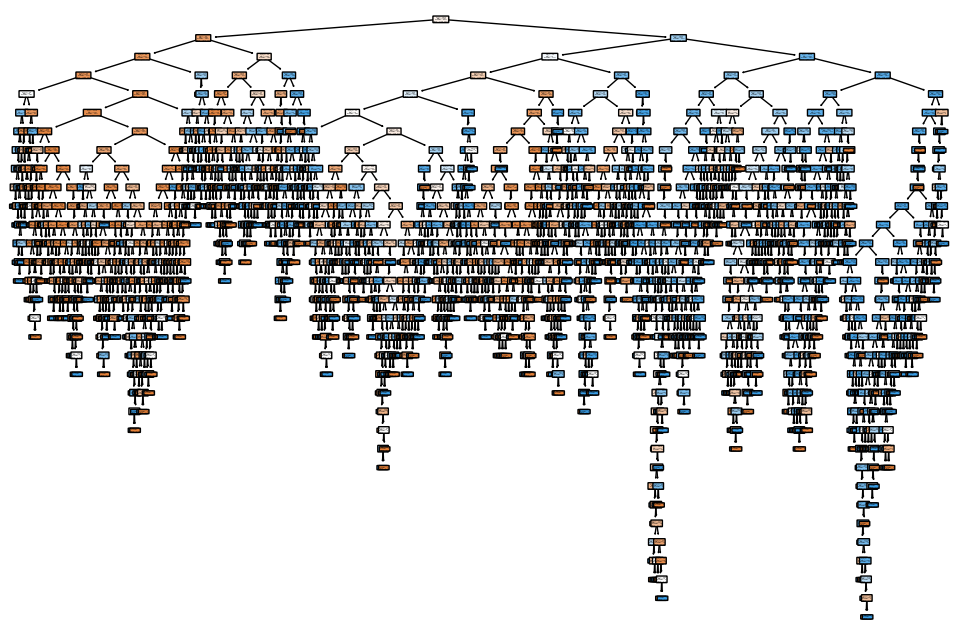

In [120]:
# import tree
from sklearn.tree import plot_tree






In [ ]:
from sklearn.tree import export_text

# Export the tree as text
tree_text = export_text(dt1)
print(tree_text)

### Save Decision Tree

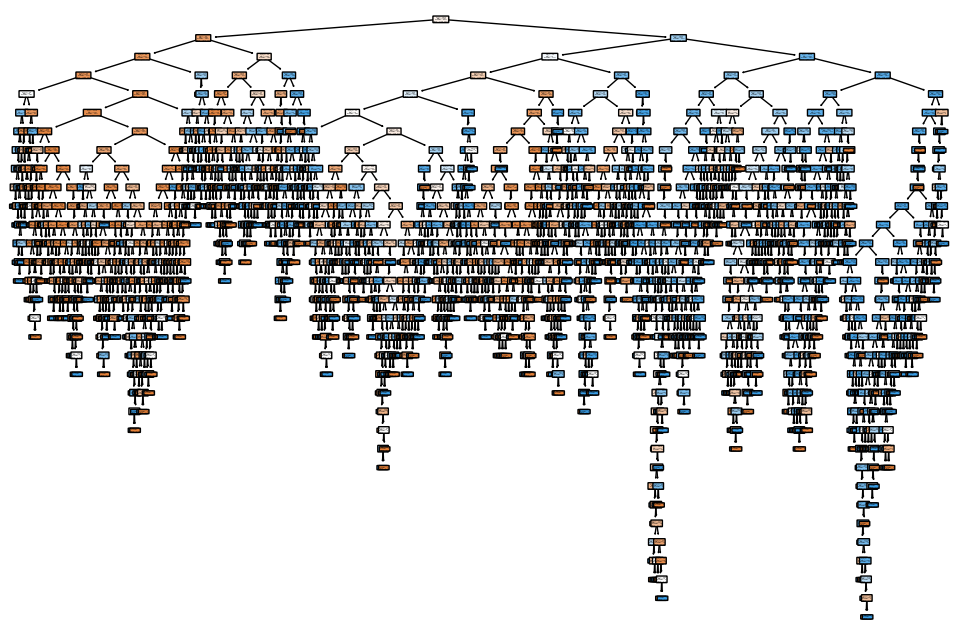

In [121]:
plt.figure(figsize=[12,8])
plot_tree(
    dt1,
    filled = True,
    rounded = True
)
plt.savefig('Base Model of Decision Tree.png',dpi=300)

### Model3 : Decision Tree

In [125]:
'''
Building Model with Purning Techniques : 
1. Max depth
'''
for max_d in range(1,31): # 1
    # creating instance of a class
    dtm = DecisionTreeClassifier(max_depth = max_d)

    # fitting the model
    dtm.fit(xtrain,ytrain)

    # predicitng 
    ypred = dtm.predict(xtest)

    # accuracy
    print(f'Max Depth No: {max_d}, Training Accuracy: {dtm.score(xtrain,ytrain)}, Testing Accuracy: {dtm.score(xtest,ytest)}')

Max Depth No: 1, Training Accuracy: 0.7116138425355583, Testing Accuracy: 0.7098074339453649
Max Depth No: 2, Training Accuracy: 0.7116138425355583, Testing Accuracy: 0.7098074339453649
Max Depth No: 3, Training Accuracy: 0.7789226117146377, Testing Accuracy: 0.7666815942678011
Max Depth No: 4, Training Accuracy: 0.7909060365102475, Testing Accuracy: 0.7787729511867443
Max Depth No: 5, Training Accuracy: 0.8091611602643073, Testing Accuracy: 0.7886251679355127
Max Depth No: 6, Training Accuracy: 0.8243924291634002, Testing Accuracy: 0.7957904164800716
Max Depth No: 7, Training Accuracy: 0.8383917571956546, Testing Accuracy: 0.8025078369905956
Max Depth No: 8, Training Accuracy: 0.8513831336095867, Testing Accuracy: 0.7980295566502463
Max Depth No: 9, Training Accuracy: 0.8700862358606787, Testing Accuracy: 0.8020600089565607
Max Depth No: 10, Training Accuracy: 0.8895733004815769, Testing Accuracy: 0.8011643528884909
Max Depth No: 11, Training Accuracy: 0.9030126553925412, Testing Accu

### Final Model

In [127]:
# creating instance of a class
dtf = DecisionTreeClassifier(max_depth=7)

# fitting the model
dtf.fit(xtrain,ytrain)

#predicting
ypred = dtf.predict(xtest)

# accuracy of training and testing
print('Training Accuracy:',dtf.score(xtrain,ytrain))
print('Testing Accuracy:',dtf.score(xtest,ytest))

Training Accuracy: 0.8386157464441707
Testing Accuracy: 0.8025078369905956


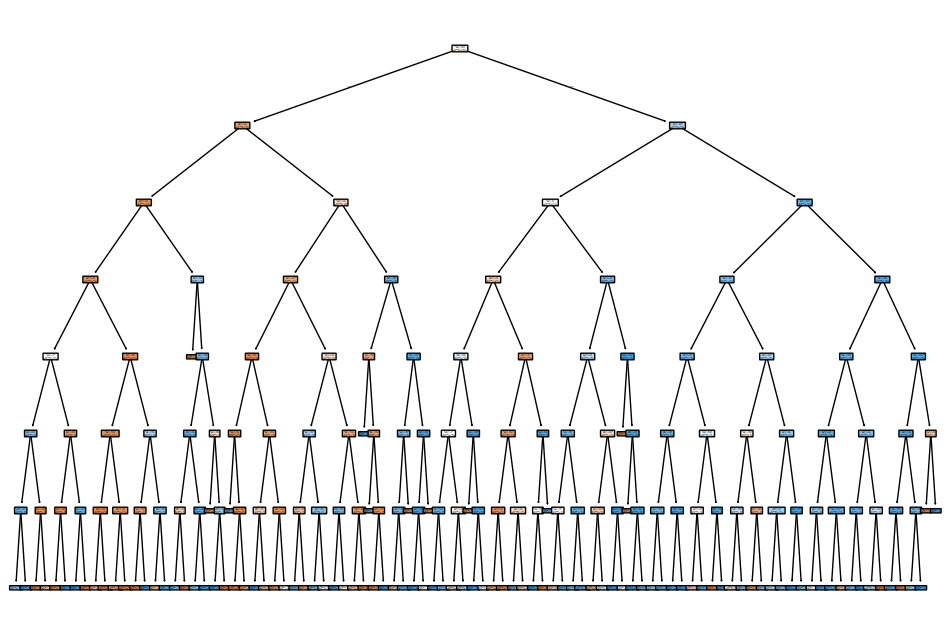

In [128]:
plt.figure(figsize=[12,8])
plot_tree(
    dtf,
    filled = True,
    rounded = True
)
plt.savefig('Final Model of Decision Tree.png')

Training Accuracy: 0.7789226117146377
Testing Accuracy: 0.7666815942678011


[Text(0.5, 0.875, 'x[3] <= 206.5\ngini = 0.499\nsamples = 8929\nvalue = [4708, 4221]'),
 Text(0.25, 0.625, 'x[5] <= 9.5\ngini = 0.325\nsamples = 3607\nvalue = [2870, 737]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[13] <= 9.5\ngini = 0.247\nsamples = 2824\nvalue = [2417, 407]'),
 Text(0.0625, 0.125, 'gini = 0.221\nsamples = 2731\nvalue = [2386, 345]'),
 Text(0.1875, 0.125, 'gini = 0.444\nsamples = 93\nvalue = [31, 62]'),
 Text(0.375, 0.375, 'x[14] <= 1.5\ngini = 0.488\nsamples = 783\nvalue = [453, 330]'),
 Text(0.3125, 0.125, 'gini = 0.379\nsamples = 547\nvalue = [408, 139]'),
 Text(0.4375, 0.125, 'gini = 0.309\nsamples = 236\nvalue = [45, 191]'),
 Text(0.75, 0.625, 'x[3] <= 438.5\ngini = 0.452\nsamples = 5322\nvalue = [1838, 3484]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[5] <= 1.5\ngini = 0.5\nsamples = 2772\nvalue = [1350, 1422]'),
 Text(0.5625, 0.125, 'gini = 0.474\nsamples = 1852\nvalue = [1138, 714]'),
 Text(0.6875, 0.125, 'gini = 0.355\nsamples = 920\n

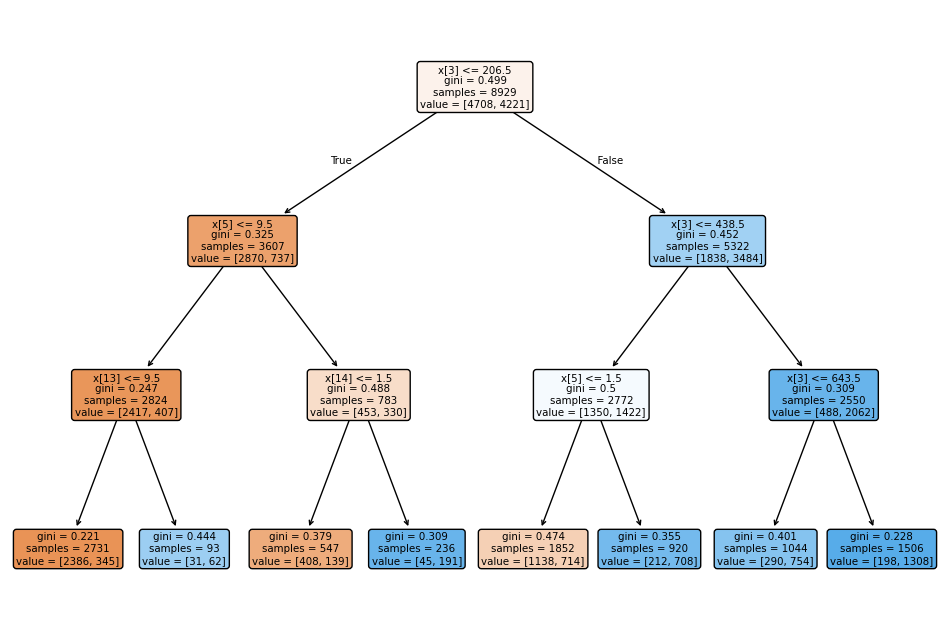

In [129]:

# creating instance of a class
dtf = DecisionTreeClassifier(max_depth=3)

# fitting the model
dtf.fit(xtrain,ytrain)

#predicting
ypred = dtf.predict(xtest)

# accuracy of training and testing
print('Training Accuracy:',dtf.score(xtrain,ytrain))
print('Testing Accuracy:',dtf.score(xtest,ytest))

plt.figure(figsize=[12,8])
plot_tree(
    dtf,
    filled = True,
    rounded = True
)

### Entropy

In [130]:
# creating instance of a class
dtf = DecisionTreeClassifier(criterion='entropy',max_depth=7)

# fitting the model
dtf.fit(xtrain,ytrain)

#predicting
ypred = dtf.predict(xtest)

# accuracy of training and testing
print('Training Accuracy:',dtf.score(xtrain,ytrain))
print('Testing Accuracy:',dtf.score(xtest,ytest))

Training Accuracy: 0.8323440474857207
Testing Accuracy: 0.8110165696372593
